## Assignment 3: $k$ Nearest Neighbor


**Q1.**
1. What is the difference between regression and classification?
2. What is a confusion table? What does it help us understand about a model's performance?
3. What does the SSE quantify about a particular model?
4. What are overfitting and underfitting?
5. Why does splitting the data into training and testing sets, and choosing $k$ by evaluating accuracy or SSE on the test set, improve model performance?
6. With classification, we can report a class label as a prediction or a probability distribution over class labels. Please explain the strengths and weaknesses of each approach.

**Q2.** This is a case study on $k$ nearest neighbor classification, using the `land_mines.csv` data.

The data consists of a label, `mine_type`, taking integer values 1 to 5, and three properties of the mine, `voltage`, `height` and `soil`. We want to predict the kind of mine from data about it. Imagine working for the DOD or a humanitarian aid agency, trying to help people remove land mines more safely.

1. Load the data. Perform some EDA, summarizing the target label and the features.
2. Split the sample 50/50 into training and test/validation sets. (The smaller the data are, the more equal the split should be, in my experience: Otherwise, all of the members of one class end up in the training or test data, and the model falls apart.)
3. Build a $k$-NN classifier. Explain how you select $k$.
4. Print a confusion table for the optimal model, comparing predicted and actual class label on the test set. How accurate is it? Where is performance more or less accurate?
5. Notice that you can have a lot of accurate predictions for a given type of mine, but still make a lot of mistakes. Please explain how you'd advise someone to actually use this predictive model in practice, given the errors that it tends to make.

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** [Jiaxian Wang]

**Date:** [10/02/2026]

Q1
1. Regression predicts numerical value, classification predicts a category or class. For example, regression could be used to predict the price or amount of sales of cars, classification could be used to predict what type of car it is, such as SUV, sedan or trucks.
2. Confusion table compares the actual classes with the classes predicted by the model. This table gives people much more details because it shows how many observations were classified correctly and where the model made mistakes.
3. SSE measures the difference between the model's predicted values and the actual values. A smaller SSE indicate that predictions are generally closer to the actual values
4. Overfitting happens when modes follow the training data too close. It performs too well on the training data but the model may not fit for the new data. Underfitting happens when a model is too simple and could not have precise predictions on both traning and new data.
5. Splitting the data into training and testing sets helps people see how well the model works on new data. People can try different values of k and compare their accuracy or SSE on the test set to have the best k.
6. A class label is more simple and easier to understand because it gives one clear prediction. However, it does not show how confident the model is. A probability distribution could give more information by showing the probability of each class, but it is harder to use and understand.

In [16]:
#Q2.1
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv("/land_mines.csv")
print(df.head())
print(df.shape)
print(df.describe())
print(df["mine_type"].value_counts().sort_index())


    voltage    height  soil  mine_type
0  0.338157  0.000000   0.0          1
1  0.320241  0.181818   0.0          1
2  0.287009  0.272727   0.0          1
3  0.256284  0.454545   0.0          1
4  0.262840  0.545455   0.0          1
(338, 4)
          voltage      height        soil   mine_type
count  338.000000  338.000000  338.000000  338.000000
mean     0.430634    0.508876    0.503550    2.952663
std      0.195819    0.306043    0.344244    1.419703
min      0.197734    0.000000    0.000000    1.000000
25%      0.309737    0.272727    0.200000    2.000000
50%      0.359516    0.545455    0.600000    3.000000
75%      0.482628    0.727273    0.800000    4.000000
max      0.999999    1.000000    1.000000    5.000000
mine_type
1    71
2    70
3    66
4    66
5    65
Name: count, dtype: int64


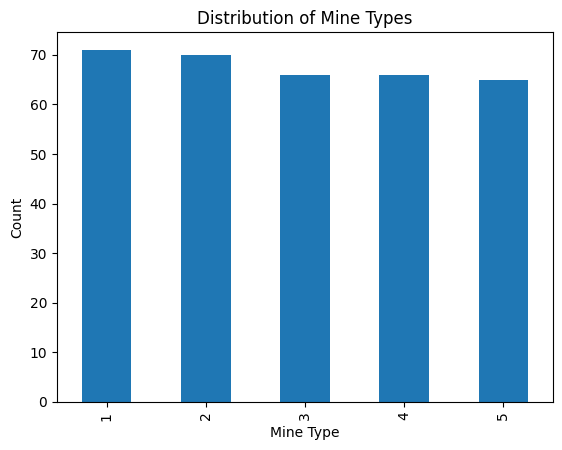

In [17]:
df["mine_type"].value_counts().sort_index().plot(kind="bar")
plt.title("Distribution of Mine Types")
plt.xlabel("Mine Type")
plt.ylabel("Count")
plt.show()

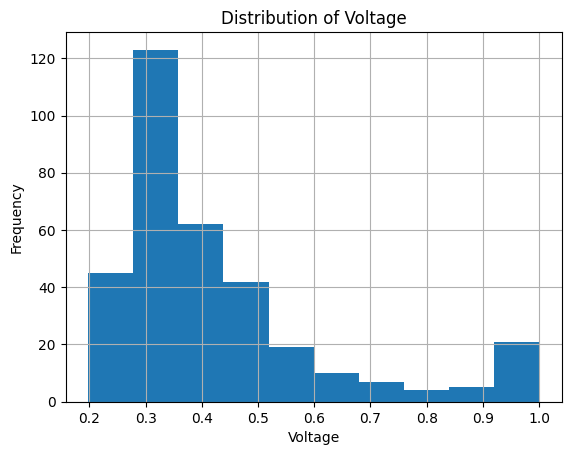

In [18]:
df["voltage"].hist()
plt.title("Distribution of Voltage")
plt.xlabel("Voltage")
plt.ylabel("Frequency")
plt.show()

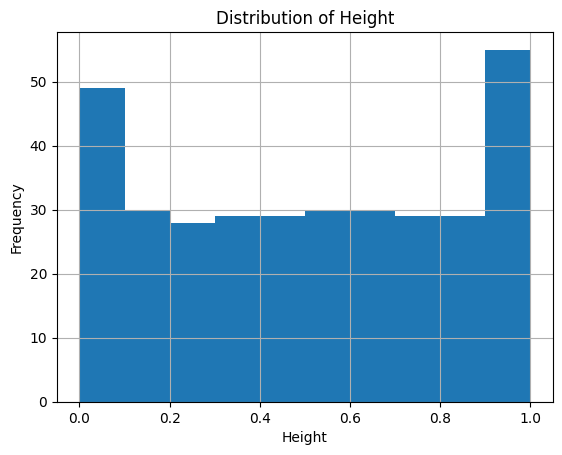

In [19]:
df["height"].hist()
plt.title("Distribution of Height")
plt.xlabel("Height")
plt.ylabel("Frequency")
plt.show()

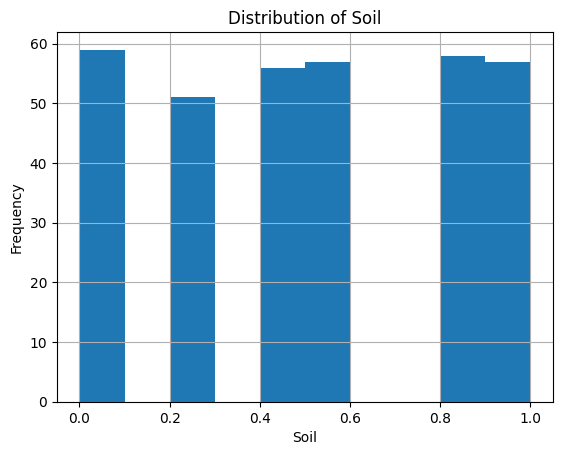

In [20]:
df["soil"].hist()
plt.title("Distribution of Soil")
plt.xlabel("Soil")
plt.ylabel("Frequency")
plt.show()

The dataset has 338 observations and 4 columns. mine_type is the target label. Voltage, height, and soil are the three features. There are five different mine types. The number of their observations in each type is mostly balanced.

In [10]:
#Q2.2
from sklearn.model_selection import train_test_split
X =df[["voltage", "height", "soil"]]
y =df["mine_type"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.5, random_state=42,)
print(X_train.shape)
print(X_test.shape)
print(y_train.value_counts().sort_index())
print(y_test.value_counts().sort_index())

(169, 3)
(169, 3)
mine_type
1    34
2    37
3    34
4    30
5    34
Name: count, dtype: int64
mine_type
1    37
2    33
3    32
4    36
5    31
Name: count, dtype: int64


In [11]:
#Q2.3
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
for k in range(1,21):
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test,y_pred)
    print(k,accuracy)

1 0.3609467455621302
2 0.40236686390532544
3 0.35502958579881655
4 0.3609467455621302
5 0.3609467455621302
6 0.3076923076923077
7 0.33136094674556216
8 0.31952662721893493
9 0.33727810650887574
10 0.3727810650887574
11 0.35502958579881655
12 0.3136094674556213
13 0.3609467455621302
14 0.33136094674556216
15 0.31952662721893493
16 0.33727810650887574
17 0.3254437869822485
18 0.31952662721893493
19 0.2958579881656805
20 0.3076923076923077


I tested k values from 1 to 20 and compared their accuracy. I choose k = 2 because it has the highest accuracy of 40.24%.

In [21]:
#Q2.4
from sklearn.metrics import confusion_matrix, accuracy_score
model = KNeighborsClassifier(n_neighbors=2)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(confusion_matrix(y_test, y_pred))
print(accuracy_score(y_test, y_pred))

[[17  0 18  2  0]
 [ 0 25  4  4  0]
 [ 8  3 16  2  3]
 [12  5 10  7  2]
 [ 8  2 12  6  3]]
0.40236686390532544


The overall accuracy is 40.24%. The model performs best on type 2. It has 25 out of 33 correctly predicted. It performs relatively well on types 1 and 3. The model seems less accurate for types 4 and 5, especially type 5. Only 3 out of 31 are correctly predicted.

Q2.5
I would not identify a mine solely based on this model, because the overall accuracy is only around 40%. The model works very well for type 2 and reasonable for type 1 and 3. However, it makes a lot of mistakes for types 4 and 5. I would use this model only as a supporting tool and combine results from other models to make the final decision.

## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** c5f67b8
- **AI tool and model used:** ChatGPT

### *Prompts used

1. Review my Phase 1 solutions for Question 1 and 2. Identify weaknesses and help me improve
2. [Paste follow-up prompt]

### *AI-proposed changes


[Paste the AI's concise numbered list verbatim.]

1. Q1.3: The explanation of SSE could be more precise. SSE is the sum of the squared differences between the actual and predicted values. A smaller SSE means the predictions are generally closer to the actual values.
2. Q1.5: The answer explains why we split the data, but it could explain the selection of \(k\) more clearly. Testing different values of \(k\) and comparing their accuracy or SSE helps us find a value that performs well on unseen data instead of only fitting the training data well.
3. Q1.6: The comparison could include more about the strengths and weaknesses of probability distributions. Probabilities provide more information because they show how confident the model is about each class and can be used with different decision thresholds. However, they are more complicated to interpret than a single class label.
4. Q2.1: The EDA is useful, but the written summary could discuss the feature distributions shown in the histograms instead of only describing the dataset size and class balance. For example, mention that voltage is concentrated more toward lower values while height and soil are more spread out.
5. Q2.4: The confusion matrix is correct, but the explanation could discuss some specific misclassification patterns. For example, many actual type 1 mines are predicted as type 3, which helps show where the model is making mistakes instead of only comparing the number of correct predictions.
6. Q2.5: The practical recommendation is reasonable, but it could connect more directly to the confusion matrix. Since the model performs especially poorly on types 4 and 5, its predictions should be verified using additional information or other identification methods before making a decision.


### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Accept| It makes the explanation of SSE more precise. |
| 2 | Accept| The suggestion makes the role of k clearer |
| 3 | Accept| Present more detail about the comparison |
| 4 | Accept| My explanation should include more about what the plots show |
| 5 | Accept| Present more details about predicting error |
| 6 | Accept| Include more details in solutions of types 4 and 5 |

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

In [ ]:
# Your Phase 2 solution to the problem goes here.

Q1
1. Regression predicts numerical value, classification predicts a category or class. For example, regression could be used to predict the price or amount of sales of cars, classification could be used to predict what type of car it is, such as SUV, sedan or trucks.
2. Confusion table compares the actual classes with the classes predicted by the model. This table gives people much more details because it shows how many observations were classified correctly and where the model made mistakes.
3. SSE is the sum of the squared differences between the actual and predicted values. It measures how far the predictions are from the actual values. A smaller SSE means the predictions are generally closer to the actual values.
4. Overfitting happens when modes follow the training data too close. It performs too well on the training data but the model may not fit for the new data. Underfitting happens when a model is too simple and could not have precise predictions on both traning and new data.
5. We split the data so we can see if the model also works well on data it has not seen before. We can try different values of k and compare their accuracy or SSE. This helps us choose a k that performs well on unseen data instead of only fitting the training data well.
6. A class label is simple and easy to understand because it gives one clear prediction, but it does not show how confident the model is. A probability distribution gives the probability of each class, so it shows more information about the uncertainty of the prediction. However, probabilities can be more difficult to interpret than a single class label.

In [22]:
#Q2.1
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv("/land_mines.csv")
print(df.head())
print(df.shape)
print(df.describe())
print(df["mine_type"].value_counts().sort_index())

    voltage    height  soil  mine_type
0  0.338157  0.000000   0.0          1
1  0.320241  0.181818   0.0          1
2  0.287009  0.272727   0.0          1
3  0.256284  0.454545   0.0          1
4  0.262840  0.545455   0.0          1
(338, 4)
          voltage      height        soil   mine_type
count  338.000000  338.000000  338.000000  338.000000
mean     0.430634    0.508876    0.503550    2.952663
std      0.195819    0.306043    0.344244    1.419703
min      0.197734    0.000000    0.000000    1.000000
25%      0.309737    0.272727    0.200000    2.000000
50%      0.359516    0.545455    0.600000    3.000000
75%      0.482628    0.727273    0.800000    4.000000
max      0.999999    1.000000    1.000000    5.000000
mine_type
1    71
2    70
3    66
4    66
5    65
Name: count, dtype: int64


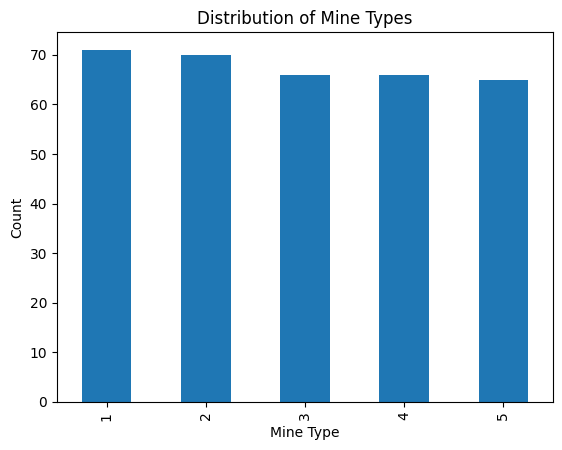

In [23]:
df["mine_type"].value_counts().sort_index().plot(kind="bar")
plt.title("Distribution of Mine Types")
plt.xlabel("Mine Type")
plt.ylabel("Count")
plt.show()

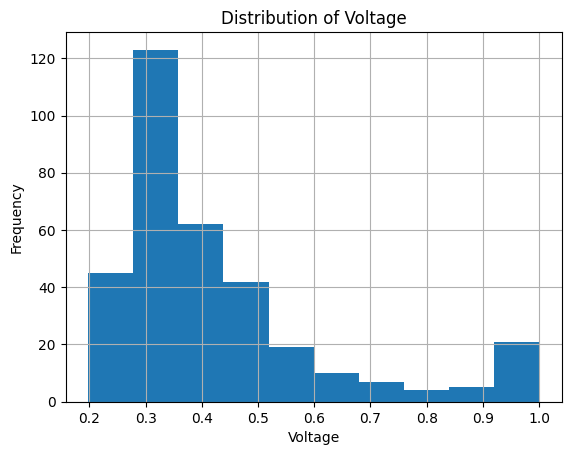

In [24]:
df["voltage"].hist()
plt.title("Distribution of Voltage")
plt.xlabel("Voltage")
plt.ylabel("Frequency")
plt.show()

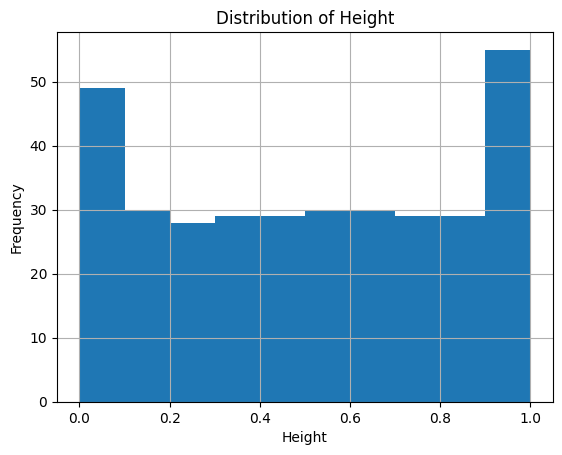

In [25]:
df["height"].hist()
plt.title("Distribution of Height")
plt.xlabel("Height")
plt.ylabel("Frequency")
plt.show()

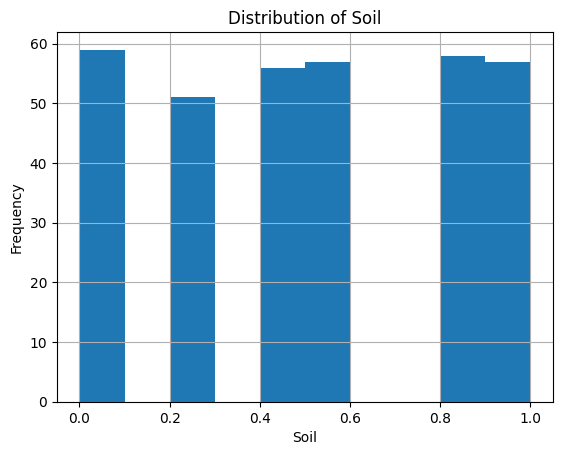

In [26]:
df["soil"].hist()
plt.title("Distribution of Soil")
plt.xlabel("Soil")
plt.ylabel("Frequency")
plt.show()

The dataset has 338 observations and 4 columns. mine_type is the target label. Voltage, height, and soil are the three features. There are five different mine types. The number of their observations in each type is mostly balanced. From the histograms, voltage has more observations at lower values, while height and soil are more spread out across their ranges.

In [27]:
#Q2.2
from sklearn.model_selection import train_test_split
X =df[["voltage", "height", "soil"]]
y =df["mine_type"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.5, random_state=42,)
print(X_train.shape)
print(X_test.shape)
print(y_train.value_counts().sort_index())
print(y_test.value_counts().sort_index())

(169, 3)
(169, 3)
mine_type
1    34
2    37
3    34
4    30
5    34
Name: count, dtype: int64
mine_type
1    37
2    33
3    32
4    36
5    31
Name: count, dtype: int64


In [28]:
#Q2.3
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
for k in range(1,21):
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test,y_pred)
    print(k,accuracy)

1 0.3609467455621302
2 0.40236686390532544
3 0.35502958579881655
4 0.3609467455621302
5 0.3609467455621302
6 0.3076923076923077
7 0.33136094674556216
8 0.31952662721893493
9 0.33727810650887574
10 0.3727810650887574
11 0.35502958579881655
12 0.3136094674556213
13 0.3609467455621302
14 0.33136094674556216
15 0.31952662721893493
16 0.33727810650887574
17 0.3254437869822485
18 0.31952662721893493
19 0.2958579881656805
20 0.3076923076923077


I tested k values from 1 to 20 and compared their accuracy. I choose k = 2 because it has the highest accuracy of 40.24%.

In [29]:
#Q2.4
from sklearn.metrics import confusion_matrix, accuracy_score
model = KNeighborsClassifier(n_neighbors=2)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(confusion_matrix(y_test, y_pred))
print(accuracy_score(y_test, y_pred))

[[17  0 18  2  0]
 [ 0 25  4  4  0]
 [ 8  3 16  2  3]
 [12  5 10  7  2]
 [ 8  2 12  6  3]]
0.40236686390532544


The overall accuracy is 40.24%. The model performs best on type 2. It has 25 out of 33 correctly predicted. It performs relatively well on types 1 and 3. The model seems less accurate for types 4 and 5, especially type 5. Only 3 out of 31 are correctly predicted.

Q2.5
I would not use this model as the only way to identify a mine because the overall accuracy is only about 40%. The model performs especially poorly on types 4 and 5. Since identifying a mine incorrectly could be dangerous, I would use this model only as a supporting tool and verify its predictions with additional information or other identification methods before removing the mine.

### *Reflection on AI assistance
In your own words without generative AI.

My overall solution did not change very much after revised by AI. Most of my original code, structure, and main ideas stayed the same. As the semester goes, I needed less help from AI with the actual code and the main content. However, AI is still useful helping me notice smaller detaill problems in my explanations. For example, some of my original answers were correct but were too general. AI suggestions really helped me explain concepts more clearly and precisely. The limitation of AI seems to be too friendly. It never changes my structure of solutions or codes. Its suggestions are based on my existing structure or ideas. I don't know what will happen if I make major mistakes, such as misunderstanding the question and writing code based on an incorrect idea. I don't have other remaining concerns, but this probably means I should be more careful when completing Phase 1 next time.